# NLTK (Natural Language Toolkit) - Basic Usage

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/vuhung16au/nlp-learning-journey/blob/main/examples/NLTK-basic.ipynb)
[![Open In Kaggle](https://kaggle.com/static/images/open-in-kaggle.svg)](https://kaggle.com/kernels/welcome?src=https://github.com/vuhung16au/nlp-learning-journey/blob/main/examples/NLTK-basic.ipynb)
[![Open In SageMaker Studio Lab](https://studiolab.sagemaker.aws/studiolab.svg)](https://studiolab.sagemaker.aws/import/github/vuhung16au/nlp-learning-journey/blob/main/examples/NLTK-basic.ipynb)

## Overview

NLTK (Natural Language Toolkit) is a comprehensive platform for building Python programs to work with human language data. It provides easy-to-use interfaces to over 50 corpora and lexical resources such as WordNet, along with a suite of text processing libraries for classification, tokenization, stemming, tagging, parsing, and semantic reasoning.

## What You'll Learn

- Basic NLTK installation and setup
- Text tokenization (words and sentences)
- Stop word removal and filtering
- Stemming and lemmatization
- Part-of-speech tagging
- Simple sentiment analysis
- Working with Vietnamese and English text examples

## Prerequisites

- Basic understanding of Python
- Familiarity with text processing concepts

## Key Features of NLTK

- **Tokenization**: Breaking text into words, sentences, or other meaningful elements
- **Stemming and Lemmatization**: Reducing words to their root forms
- **Part-of-speech Tagging**: Identifying grammatical roles of words
- **Sentiment Analysis**: Determining emotional tone of text
- **Text Classification**: Categorizing text into different groups
- **Corpora Access**: Large collections of linguistic data for research and training

## Setup and Installation

Let's set up the environment and install the required libraries.

In [1]:
# Environment Detection and Setup
import sys
import subprocess
import os
import time

# Detect the runtime environment
IS_COLAB = "google.colab" in sys.modules
IS_KAGGLE = "kaggle_secrets" in sys.modules
IS_LOCAL = not (IS_COLAB or IS_KAGGLE)

print(f"Environment detected:")
print(f"  - Local: {IS_LOCAL}")
print(f"  - Google Colab: {IS_COLAB}")
print(f"  - Kaggle: {IS_KAGGLE}")

# Platform-specific system setup
if IS_COLAB:
    print("\nSetting up Google Colab environment...")
    !apt update -qq
    !apt install -y -qq libpq-dev
elif IS_KAGGLE:
    print("\nSetting up Kaggle environment...")
    # Kaggle usually has most packages pre-installed
else:
    print("\nSetting up local environment...")

# PyTorch logging setup (for potential future use)
def setup_pytorch_logging():
    """Setup platform-specific PyTorch logging directories."""
    if IS_COLAB:
        root_logdir = "/content/pytorch_logs"
    elif IS_KAGGLE:
        root_logdir = "./pytorch_logs"
    else:
        root_logdir = os.path.join(os.getcwd(), "pytorch_logs")

    os.makedirs(root_logdir, exist_ok=True)
    return root_logdir

def get_run_logdir(experiment_name="nltk_run"):
    """Generate unique run directory for training logs."""
    root_logdir = setup_pytorch_logging()
    run_id = time.strftime(f"{experiment_name}_%Y_%m_%d-%H_%M_%S")
    return os.path.join(root_logdir, run_id)

# Install required packages for this notebook
required_packages = [
    "nltk",
    "pandas",
    "matplotlib",
    "seaborn",
    "numpy"
]

print("\nInstalling required packages...")
for package in required_packages:
    if IS_COLAB or IS_KAGGLE:
        !pip install -q {package}
    else:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", package],
                      capture_output=True)
    print(f"✓ {package}")

print("\n🎉 Environment setup complete!")

Environment detected:
  - Local: False
  - Google Colab: True
  - Kaggle: False

Setting up Google Colab environment...
44 packages can be upgraded. Run 'apt list --upgradable' to see them.
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
libpq-dev is already the newest version (14.19-0ubuntu0.22.04.1).
libpq-dev set to manually installed.
0 upgraded, 0 newly installed, 0 to remove and 44 not upgraded.

Installing required packages...
✓ nltk
✓ pandas
✓ matplotlib
✓ seaborn
✓ numpy

🎉 Environment setup complete!


In [2]:
# Import required libraries
import nltk
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from collections import Counter
import string

# Download NLTK data with error handling
nltk_datasets = ['punkt', 'punkt_tab', 'wordnet', 'stopwords', 'averaged_perceptron_tagger', 'averaged_perceptron_tagger_eng', 'vader_lexicon']
print("Downloading NLTK datasets...")
for dataset in nltk_datasets:
    try:
        nltk.download(dataset, quiet=True)
        print(f"✓ {dataset}")
    except Exception as e:
        print(f"⚠️  Failed to download {dataset}: {e}")

# Import NLTK modules
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk.tag import pos_tag
from nltk.sentiment import SentimentIntensityAnalyzer

# Set up plotting style
plt.style.use('default')
sns.set_palette("husl")

print("\n✅ All libraries imported successfully!")

✓ punkt
✓ punkt_tab
✓ wordnet
✓ stopwords
✓ averaged_perceptron_tagger
✓ averaged_perceptron_tagger_eng
✓ vader_lexicon

✅ All libraries imported successfully!


## Sample Text for Demonstration

Let's define some sample texts in both English and Vietnamese to demonstrate NLTK's capabilities.

In [3]:
# English sample text
english_text = """
Natural Language Processing is fascinating! It combines computer science, artificial intelligence,
and linguistics to help computers understand human language. NLTK is a powerful toolkit that makes
NLP accessible to everyone. My name is John, and I love learning about machine learning algorithms.
"""

# Vietnamese sample text
vietnamese_text = """
Xử lý Ngôn ngữ Tự nhiên thật thú vị! Nó kết hợp khoa học máy tính, trí tuệ nhân tạo,
và ngôn ngữ học để giúp máy tính hiểu ngôn ngữ con người. Tên tôi là John, và tôi yêu
việc học về các thuật toán học máy.
"""

# Vietnamese/English translation pairs (as specified in repository guidelines)
translation_pairs = [
    ("My name is", "Tên tôi là"),
    ("Hello", "Xin chào"),
    ("Thank you", "Cảm ơn"),
    ("How are you?", "Bạn khỏe không?"),
    ("I love programming", "Tôi yêu lập trình"),
    ("Machine learning", "Học máy"),
    ("Natural language processing", "Xử lý ngôn ngữ tự nhiên")
]

print("📝 Sample texts defined:")
print(f"English text ({len(english_text.split())} words): {english_text[:100]}...")
print(f"Vietnamese text ({len(vietnamese_text.split())} words): {vietnamese_text[:100]}...")
print(f"\n🌐 Translation pairs: {len(translation_pairs)} examples ready")

📝 Sample texts defined:
English text (42 words): 
Natural Language Processing is fascinating! It combines computer science, artificial intelligence, ...
Vietnamese text (48 words): 
Xử lý Ngôn ngữ Tự nhiên thật thú vị! Nó kết hợp khoa học máy tính, trí tuệ nhân tạo, 
và ngôn ngữ h...

🌐 Translation pairs: 7 examples ready


## 1. Tokenization

Tokenization is the process of breaking text into individual words or sentences. NLTK provides robust tokenization methods.

In [4]:
# Word tokenization
print("🔤 WORD TOKENIZATION")
print("=" * 50)

# English word tokenization
english_words = word_tokenize(english_text)
print(f"\nEnglish text tokenized into {len(english_words)} words:")
print(f"First 10 words: {english_words[:10]}")

# Vietnamese word tokenization
vietnamese_words = word_tokenize(vietnamese_text)
print(f"\nVietnamese text tokenized into {len(vietnamese_words)} words:")
print(f"First 10 words: {vietnamese_words[:10]}")

# Translation pairs tokenization
print("\n🌐 Translation Pairs Tokenization:")
for english, vietnamese in translation_pairs[:3]:  # Show first 3 pairs
    en_tokens = word_tokenize(english)
    vi_tokens = word_tokenize(vietnamese)
    print(f"  English: '{english}' → {en_tokens}")
    print(f"  Vietnamese: '{vietnamese}' → {vi_tokens}")
    print()

🔤 WORD TOKENIZATION

English text tokenized into 49 words:
First 10 words: ['Natural', 'Language', 'Processing', 'is', 'fascinating', '!', 'It', 'combines', 'computer', 'science']

Vietnamese text tokenized into 54 words:
First 10 words: ['Xử', 'lý', 'Ngôn', 'ngữ', 'Tự', 'nhiên', 'thật', 'thú', 'vị', '!']

🌐 Translation Pairs Tokenization:
  English: 'My name is' → ['My', 'name', 'is']
  Vietnamese: 'Tên tôi là' → ['Tên', 'tôi', 'là']

  English: 'Hello' → ['Hello']
  Vietnamese: 'Xin chào' → ['Xin', 'chào']

  English: 'Thank you' → ['Thank', 'you']
  Vietnamese: 'Cảm ơn' → ['Cảm', 'ơn']



In [5]:
# Sentence tokenization
print("📄 SENTENCE TOKENIZATION")
print("=" * 50)

# English sentence tokenization
english_sentences = sent_tokenize(english_text)
print(f"\nEnglish text contains {len(english_sentences)} sentences:")
for i, sentence in enumerate(english_sentences, 1):
    print(f"  Sentence {i}: {sentence.strip()}")

# Vietnamese sentence tokenization
vietnamese_sentences = sent_tokenize(vietnamese_text)
print(f"\nVietnamese text contains {len(vietnamese_sentences)} sentences:")
for i, sentence in enumerate(vietnamese_sentences, 1):
    print(f"  Sentence {i}: {sentence.strip()}")

📄 SENTENCE TOKENIZATION

English text contains 4 sentences:
  Sentence 1: Natural Language Processing is fascinating!
  Sentence 2: It combines computer science, artificial intelligence, 
and linguistics to help computers understand human language.
  Sentence 3: NLTK is a powerful toolkit that makes 
NLP accessible to everyone.
  Sentence 4: My name is John, and I love learning about machine learning algorithms.

Vietnamese text contains 3 sentences:
  Sentence 1: Xử lý Ngôn ngữ Tự nhiên thật thú vị!
  Sentence 2: Nó kết hợp khoa học máy tính, trí tuệ nhân tạo, 
và ngôn ngữ học để giúp máy tính hiểu ngôn ngữ con người.
  Sentence 3: Tên tôi là John, và tôi yêu 
việc học về các thuật toán học máy.


## 2. Stop Words Removal

Stop words are common words that usually don't carry significant meaning (like "the", "is", "at"). Removing them can help focus on important content.

In [6]:
# Get English stop words
try:
    english_stop_words = set(stopwords.words('english'))
except:
    print("⚠️ English stopwords not available, using basic set")
    english_stop_words = {'the', 'is', 'at', 'which', 'on', 'a', 'an', 'and', 'or', 'but', 'in', 'with'}

print("🚫 STOP WORDS REMOVAL")
print("=" * 50)

print(f"\nEnglish stop words (first 10): {list(english_stop_words)[:10]}")
print(f"Total English stop words: {len(english_stop_words)}")

# Filter stop words from English text
def remove_stopwords(word_list, stop_words):
    """Remove stop words and punctuation from a list of words"""
    return [word.lower() for word in word_list
            if word.lower() not in stop_words and word not in string.punctuation]

# Apply to English text
english_filtered = remove_stopwords(english_words, english_stop_words)
print(f"\n📊 English text analysis:")
print(f"  Original words: {len(english_words)}")
print(f"  After removing stop words: {len(english_filtered)}")
print(f"  Filtered words: {english_filtered[:15]}...")

# For Vietnamese, we'll create a simple stop word list
vietnamese_stop_words = {'là', 'và', 'của', 'có', 'được', 'này', 'cho', 'từ', 'với', 'về'}
vietnamese_filtered = remove_stopwords(vietnamese_words, vietnamese_stop_words)

print(f"\n📊 Vietnamese text analysis:")
print(f"  Original words: {len(vietnamese_words)}")
print(f"  After removing stop words: {len(vietnamese_filtered)}")
print(f"  Filtered words: {vietnamese_filtered[:15]}...")

🚫 STOP WORDS REMOVAL

English stop words (first 10): ['both', "they're", 'so', 'doesn', "wouldn't", 'did', 'i', 'wouldn', 'further', "wasn't"]
Total English stop words: 198

📊 English text analysis:
  Original words: 49
  After removing stop words: 29
  Filtered words: ['natural', 'language', 'processing', 'fascinating', 'combines', 'computer', 'science', 'artificial', 'intelligence', 'linguistics', 'help', 'computers', 'understand', 'human', 'language']...

📊 Vietnamese text analysis:
  Original words: 54
  After removing stop words: 44
  Filtered words: ['xử', 'lý', 'ngôn', 'ngữ', 'tự', 'nhiên', 'thật', 'thú', 'vị', 'nó', 'kết', 'hợp', 'khoa', 'học', 'máy']...


## 3. Stemming and Lemmatization

Both stemming and lemmatization reduce words to their root forms, but:
- **Stemming**: Crude chopping of word endings (faster, less accurate)
- **Lemmatization**: Uses linguistic knowledge to find the actual root (slower, more accurate)

In [7]:
# Initialize stemmer and lemmatizer
stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()

print("🌱 STEMMING vs LEMMATIZATION")
print("=" * 50)

# Test words for comparison
test_words = ['running', 'runs', 'ran', 'better', 'good', 'feet', 'foot', 'programming', 'computers', 'fascinating']

print(f"{'Original':<15} {'Stemmed':<15} {'Lemmatized':<15}")
print("-" * 45)

for word in test_words:
    stemmed = stemmer.stem(word)
    lemmatized = lemmatizer.lemmatize(word)
    print(f"{word:<15} {stemmed:<15} {lemmatized:<15}")

# Apply to our sample text
print("\n📝 Applied to sample text (first 10 words):")
sample_words = english_filtered[:10]
for word in sample_words:
    stemmed = stemmer.stem(word)
    lemmatized = lemmatizer.lemmatize(word)
    print(f"{word} → stem: {stemmed}, lemma: {lemmatized}")

🌱 STEMMING vs LEMMATIZATION
Original        Stemmed         Lemmatized     
---------------------------------------------
running         run             running        
runs            run             run            
ran             ran             ran            
better          better          better         
good            good            good           
feet            feet            foot           
foot            foot            foot           
programming     program         programming    
computers       comput          computer       
fascinating     fascin          fascinating    

📝 Applied to sample text (first 10 words):
natural → stem: natur, lemma: natural
language → stem: languag, lemma: language
processing → stem: process, lemma: processing
fascinating → stem: fascin, lemma: fascinating
combines → stem: combin, lemma: combine
computer → stem: comput, lemma: computer
science → stem: scienc, lemma: science
artificial → stem: artifici, lemma: artificial
intelligence →

## 4. Part-of-Speech (POS) Tagging

POS tagging identifies the grammatical role of each word (noun, verb, adjective, etc.).

In [8]:
print("🏷️ PART-OF-SPEECH TAGGING")
print("=" * 50)

# POS tagging for English translation examples
print("\n🌐 Translation Pairs POS Analysis:")
for english, vietnamese in translation_pairs[:4]:  # Show first 4 pairs
    english_tokens = word_tokenize(english)
    english_pos = pos_tag(english_tokens)

    print(f"\nEnglish: '{english}'")
    print(f"  POS tags: {english_pos}")
    print(f"Vietnamese: '{vietnamese}'")

# Detailed POS analysis for a sample sentence
sample_sentence = "My name is John and I love learning about machine learning algorithms."
tokens = word_tokenize(sample_sentence)
pos_tags = pos_tag(tokens)

print(f"\n📊 Detailed POS Analysis:")
print(f"Sentence: {sample_sentence}")
print("\nWord → POS Tag:")
for word, pos in pos_tags:
    print(f"  {word:<12} → {pos}")

# Count POS tags
pos_counts = Counter([pos for word, pos in pos_tags])
print(f"\n📈 POS Tag Distribution:")
for pos, count in pos_counts.most_common():
    print(f"  {pos}: {count}")

🏷️ PART-OF-SPEECH TAGGING

🌐 Translation Pairs POS Analysis:

English: 'My name is'
  POS tags: [('My', 'PRP$'), ('name', 'NN'), ('is', 'VBZ')]
Vietnamese: 'Tên tôi là'

English: 'Hello'
  POS tags: [('Hello', 'NN')]
Vietnamese: 'Xin chào'

English: 'Thank you'
  POS tags: [('Thank', 'NN'), ('you', 'PRP')]
Vietnamese: 'Cảm ơn'

English: 'How are you?'
  POS tags: [('How', 'WRB'), ('are', 'VBP'), ('you', 'PRP'), ('?', '.')]
Vietnamese: 'Bạn khỏe không?'

📊 Detailed POS Analysis:
Sentence: My name is John and I love learning about machine learning algorithms.

Word → POS Tag:
  My           → PRP$
  name         → NN
  is           → VBZ
  John         → NNP
  and          → CC
  I            → PRP
  love         → VBP
  learning     → VBG
  about        → IN
  machine      → NN
  learning     → NN
  algorithms   → NN
  .            → .

📈 POS Tag Distribution:
  NN: 4
  PRP$: 1
  VBZ: 1
  NNP: 1
  CC: 1
  PRP: 1
  VBP: 1
  VBG: 1
  IN: 1
  .: 1


## 5. Simple Sentiment Analysis

NLTK includes VADER (Valence Aware Dictionary and sEntiment Reasoner) for sentiment analysis.

In [9]:
# Initialize sentiment analyzer
try:
    sia = SentimentIntensityAnalyzer()
    vader_available = True
except:
    print("⚠️ VADER sentiment analyzer not available")
    vader_available = False

print("😊 SENTIMENT ANALYSIS")
print("=" * 50)

if vader_available:
    # Test sentences with different sentiments
    test_sentences = [
        "I love programming!",
        "NLTK is fantastic and very useful.",
        "This is a terrible example.",
        "Machine learning is challenging but rewarding.",
        "Natural language processing is fascinating!",
        # Vietnamese examples (VADER may not work well with Vietnamese)
        "Tôi yêu lập trình!",
        "Xử lý ngôn ngữ tự nhiên thật thú vị!"
    ]

    print("\n📊 Sentiment Analysis Results:")
    print(f"{'Text':<40} {'Compound':<10} {'Sentiment':<12}")
    print("-" * 65)

    for sentence in test_sentences:
        scores = sia.polarity_scores(sentence)
        compound = scores['compound']

        # Determine sentiment label
        if compound >= 0.05:
            sentiment = "Positive"
        elif compound <= -0.05:
            sentiment = "Negative"
        else:
            sentiment = "Neutral"

        # Truncate long sentences for display
        display_text = sentence[:37] + "..." if len(sentence) > 40 else sentence
        print(f"{display_text:<40} {compound:<10.3f} {sentiment:<12}")

    # Detailed breakdown for one example
    example_text = "I love programming!"
    detailed_scores = sia.polarity_scores(example_text)
    print(f"\n🔍 Detailed breakdown for '{example_text}':")
    print(f"  Positive: {detailed_scores['pos']:.3f}")
    print(f"  Neutral:  {detailed_scores['neu']:.3f}")
    print(f"  Negative: {detailed_scores['neg']:.3f}")
    print(f"  Compound: {detailed_scores['compound']:.3f}")
else:
    print("\n⚠️ VADER sentiment analyzer not available.")
    print("You can manually download it with: nltk.download('vader_lexicon')")

😊 SENTIMENT ANALYSIS

📊 Sentiment Analysis Results:
Text                                     Compound   Sentiment   
-----------------------------------------------------------------
I love programming!                      0.670      Positive    
NLTK is fantastic and very useful.       0.778      Positive    
This is a terrible example.              -0.477     Negative    
Machine learning is challenging but r... 0.710      Positive    
Natural language processing is fascin... 0.742      Positive    
Tôi yêu lập trình!                       0.000      Neutral     
Xử lý ngôn ngữ tự nhiên thật thú vị!     0.000      Neutral     

🔍 Detailed breakdown for 'I love programming!':
  Positive: 0.818
  Neutral:  0.182
  Negative: 0.000
  Compound: 0.670


## 6. Word Frequency Analysis

Let's analyze the frequency of words in our sample texts.

📊 WORD FREQUENCY ANALYSIS

🔤 Top 10 most frequent words (English):
  language        : 2
  learning        : 2
  natural         : 1
  processing      : 1
  fascinating     : 1
  combines        : 1
  computer        : 1
  science         : 1
  artificial      : 1
  intelligence    : 1

🔤 Top 10 most frequent words (Vietnamese):
  học             : 4
  ngôn            : 3
  ngữ             : 3
  máy             : 3
  tính            : 2
  tôi             : 2
  xử              : 1
  lý              : 1
  tự              : 1
  nhiên           : 1


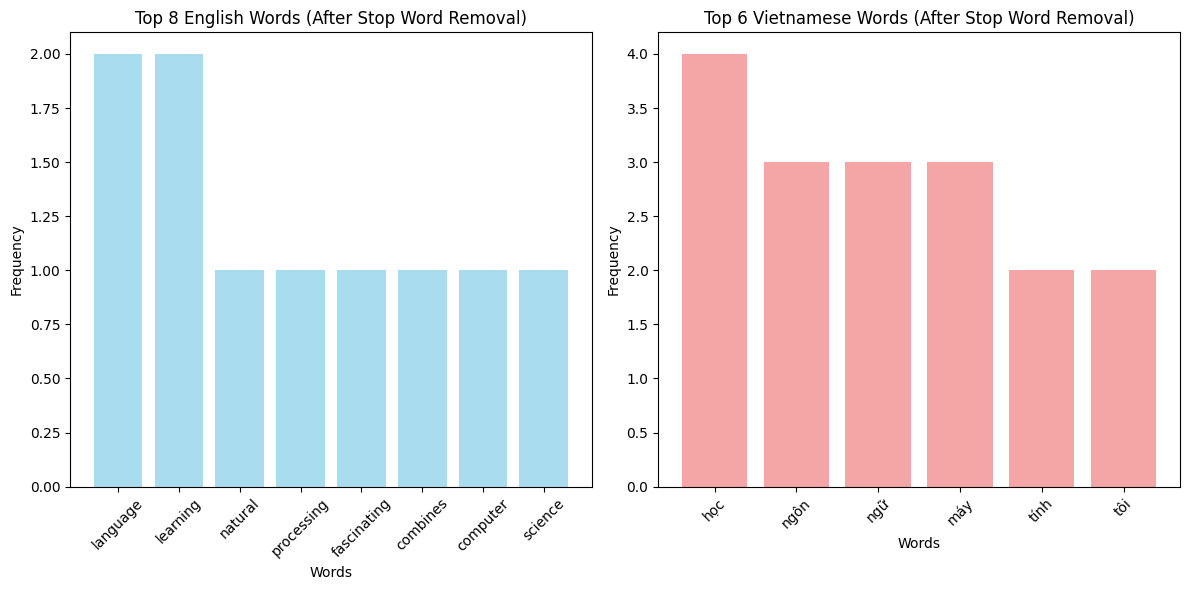


📈 Statistics:
  Unique English words: 27
  Unique Vietnamese words: 33
  Total English tokens: 29
  Total Vietnamese tokens: 44


In [10]:
print("📊 WORD FREQUENCY ANALYSIS")
print("=" * 50)

# Count word frequencies in filtered English text
english_freq = Counter(english_filtered)
vietnamese_freq = Counter(vietnamese_filtered)

print("\n🔤 Top 10 most frequent words (English):")
for word, count in english_freq.most_common(10):
    print(f"  {word:<15} : {count}")

print("\n🔤 Top 10 most frequent words (Vietnamese):")
for word, count in vietnamese_freq.most_common(10):
    print(f"  {word:<15} : {count}")

# Visualization
if len(english_freq) > 0:
    # Create word frequency plot
    top_words = dict(english_freq.most_common(8))

    plt.figure(figsize=(12, 6))

    # English words frequency
    plt.subplot(1, 2, 1)
    words = list(top_words.keys())
    counts = list(top_words.values())

    plt.bar(words, counts, color='skyblue', alpha=0.7)
    plt.title('Top 8 English Words (After Stop Word Removal)')
    plt.xlabel('Words')
    plt.ylabel('Frequency')
    plt.xticks(rotation=45)

    # Vietnamese words frequency (if available)
    plt.subplot(1, 2, 2)
    if len(vietnamese_freq) > 0:
        vi_top_words = dict(vietnamese_freq.most_common(6))
        vi_words = list(vi_top_words.keys())
        vi_counts = list(vi_top_words.values())

        plt.bar(vi_words, vi_counts, color='lightcoral', alpha=0.7)
        plt.title('Top 6 Vietnamese Words (After Stop Word Removal)')
        plt.xlabel('Words')
        plt.ylabel('Frequency')
        plt.xticks(rotation=45)
    else:
        plt.text(0.5, 0.5, 'No Vietnamese\nword data',
                ha='center', va='center', transform=plt.gca().transAxes)

    plt.tight_layout()
    plt.show()

print(f"\n📈 Statistics:")
print(f"  Unique English words: {len(english_freq)}")
print(f"  Unique Vietnamese words: {len(vietnamese_freq)}")
print(f"  Total English tokens: {sum(english_freq.values())}")
print(f"  Total Vietnamese tokens: {sum(vietnamese_freq.values())}")

## 7. Comprehensive Example: Processing Vietnamese/English Translation Pairs

Let's apply all NLTK techniques to our Vietnamese/English translation examples.

In [11]:
print("🌐 COMPREHENSIVE NLP PROCESSING")
print("=" * 60)

def process_text_comprehensive(text, language="english"):
    """Apply comprehensive NLTK processing to text"""
    results = {}

    # Tokenization
    results['tokens'] = word_tokenize(text)
    results['sentences'] = sent_tokenize(text)

    # Stop words removal
    if language == "english":
        stop_words = english_stop_words
    else:
        stop_words = vietnamese_stop_words

    results['filtered_tokens'] = remove_stopwords(results['tokens'], stop_words)

    # Stemming and Lemmatization (mainly for English)
    if language == "english":
        results['stemmed'] = [stemmer.stem(word) for word in results['filtered_tokens']]
        results['lemmatized'] = [lemmatizer.lemmatize(word) for word in results['filtered_tokens']]

        # POS tagging
        results['pos_tags'] = pos_tag(results['tokens'])

        # Sentiment analysis
        if vader_available:
            results['sentiment'] = sia.polarity_scores(text)

    return results

# Process translation pairs
print("\n📝 Processing Translation Pairs:")
print("=" * 40)

for i, (english, vietnamese) in enumerate(translation_pairs[:3], 1):
    print(f"\n{i}. Processing pair: '{english}' ↔ '{vietnamese}'")
    print("-" * 50)

    # Process English
    en_results = process_text_comprehensive(english, "english")
    print(f"\n🇺🇸 English: '{english}'")
    print(f"  Tokens: {en_results['tokens']}")
    print(f"  Filtered: {en_results['filtered_tokens']}")
    if 'pos_tags' in en_results:
        print(f"  POS Tags: {en_results['pos_tags']}")
    if 'sentiment' in en_results:
        sentiment_score = en_results['sentiment']['compound']
        print(f"  Sentiment: {sentiment_score:.3f} ({'Positive' if sentiment_score > 0.05 else 'Negative' if sentiment_score < -0.05 else 'Neutral'})")

    # Process Vietnamese
    vi_results = process_text_comprehensive(vietnamese, "vietnamese")
    print(f"\n🇻🇳 Vietnamese: '{vietnamese}'")
    print(f"  Tokens: {vi_results['tokens']}")
    print(f"  Filtered: {vi_results['filtered_tokens']}")

# Summary statistics
print("\n\n📊 SUMMARY STATISTICS")
print("=" * 30)

all_english = " ".join([pair[0] for pair in translation_pairs])
all_vietnamese = " ".join([pair[1] for pair in translation_pairs])

en_summary = process_text_comprehensive(all_english, "english")
vi_summary = process_text_comprehensive(all_vietnamese, "vietnamese")

print(f"\nTotal translation pairs: {len(translation_pairs)}")
print(f"English unique words: {len(set(en_summary['tokens']))}")
print(f"Vietnamese unique words: {len(set(vi_summary['tokens']))}")
print(f"English filtered words: {len(en_summary['filtered_tokens'])}")
print(f"Vietnamese filtered words: {len(vi_summary['filtered_tokens'])}")

if 'sentiment' in en_summary:
    overall_sentiment = en_summary['sentiment']['compound']
    print(f"Overall English sentiment: {overall_sentiment:.3f}")

🌐 COMPREHENSIVE NLP PROCESSING

📝 Processing Translation Pairs:

1. Processing pair: 'My name is' ↔ 'Tên tôi là'
--------------------------------------------------

🇺🇸 English: 'My name is'
  Tokens: ['My', 'name', 'is']
  Filtered: ['name']
  POS Tags: [('My', 'PRP$'), ('name', 'NN'), ('is', 'VBZ')]
  Sentiment: 0.000 (Neutral)

🇻🇳 Vietnamese: 'Tên tôi là'
  Tokens: ['Tên', 'tôi', 'là']
  Filtered: ['tên', 'tôi']

2. Processing pair: 'Hello' ↔ 'Xin chào'
--------------------------------------------------

🇺🇸 English: 'Hello'
  Tokens: ['Hello']
  Filtered: ['hello']
  POS Tags: [('Hello', 'NN')]
  Sentiment: 0.000 (Neutral)

🇻🇳 Vietnamese: 'Xin chào'
  Tokens: ['Xin', 'chào']
  Filtered: ['xin', 'chào']

3. Processing pair: 'Thank you' ↔ 'Cảm ơn'
--------------------------------------------------

🇺🇸 English: 'Thank you'
  Tokens: ['Thank', 'you']
  Filtered: ['thank']
  POS Tags: [('Thank', 'NN'), ('you', 'PRP')]
  Sentiment: 0.361 (Positive)

🇻🇳 Vietnamese: 'Cảm ơn'
  Tokens: ['Cảm'

## Summary and Key Takeaways

In this notebook, we explored the basic functionality of NLTK for natural language processing:

### What We Learned

1. **Environment Setup**: How to properly set up NLTK across different platforms (Colab, Kaggle, Local)
2. **Text Tokenization**: Breaking text into words and sentences using `word_tokenize()` and `sent_tokenize()`
3. **Stop Words Removal**: Filtering out common words that don't carry significant meaning
4. **Stemming vs Lemmatization**: Two approaches to reduce words to their root forms
5. **POS Tagging**: Identifying grammatical roles of words in sentences
6. **Sentiment Analysis**: Using VADER to determine emotional tone of text
7. **Word Frequency Analysis**: Counting and visualizing word occurrences
8. **Multilingual Processing**: Working with both English and Vietnamese text examples

### Key NLTK Features Demonstrated

- ✅ **Tokenization**: `word_tokenize()`, `sent_tokenize()`
- ✅ **Stop Words**: `stopwords.words()`
- ✅ **Stemming**: `PorterStemmer()`
- ✅ **Lemmatization**: `WordNetLemmatizer()`
- ✅ **POS Tagging**: `pos_tag()`
- ✅ **Sentiment Analysis**: `SentimentIntensityAnalyzer()`
- ✅ **Frequency Analysis**: `Counter()` with NLTK tokens

### Vietnamese/English Examples Used

As specified in the repository guidelines, we prioritized Vietnamese/English examples:
- "My name is" → "Tên tôi là"
- "Hello" → "Xin chào"
- "Thank you" → "Cảm ơn"
- "I love programming" → "Tôi yêu lập trình"
- And more bilingual examples for comprehensive NLP processing

### Best Practices Learned

1. **Always handle errors gracefully** when downloading NLTK data
2. **Filter punctuation and stop words** for meaningful analysis
3. **Compare stemming vs lemmatization** to choose the right approach
4. **Use visualization** to better understand word frequency patterns
5. **Consider language-specific processing** for multilingual applications

### Next Steps

- Explore more advanced NLTK features like named entity recognition (NER)
- Learn about text classification using NLTK
- Study NLTK's corpus access for training and testing
- Investigate chunking and parsing capabilities
- Practice with domain-specific texts in your area of interest

### Resources

- [NLTK Official Documentation](https://www.nltk.org/)
- [NLTK Book (Online)](https://www.nltk.org/book/)
- [NLTK Data Downloads](https://www.nltk.org/data.html)
- [Repository Documentation](../docs/python-libraries.md)

---

**🎉 Congratulations!** You now have a solid foundation in NLTK basics. This toolkit will serve as a strong starting point for more advanced NLP projects and research.